# 회귀 알고리즘의 종류

| 알고리즘                                            | 설명                         | 주요 특징           | 주요 파라미터                                                                 | 파라미터 설명                                  |
| ----------------------------------------------- | -------------------------- | --------------- | ----------------------------------------------------------------------- | ---------------------------------------- |
| **선형 회귀 (Linear Regression)**                   | 입력 변수들의 가중치 선형 결합으로 출력값 예측 | 가장 기본적인 회귀      | `fit_intercept`, `normalize`                                            | 절편 포함 여부, 입력 정규화 여부 (deprecated)         |
| **릿지 회귀 (Ridge Regression)**                    | L2 규제 추가한 선형 회귀            | 과적합 방지          | `alpha`, `solver`                                                       | 규제 강도 (α ↑일수록 규제 강함), 최적화 방법             |
| **라쏘 회귀 (Lasso Regression)**                    | L1 규제 추가                   | 변수 선택(특성 제거) 가능 | `alpha`, `max_iter`                                                     | 규제 강도, 반복 횟수 (수렴 시 사용)                   |
| **엘라스틱넷 (ElasticNet)**                          | L1 + L2 규제 혼합              | 릿지+라쏘 장점 결합     | `alpha`, `l1_ratio`                                                     | 규제 강도, L1\:L2 비율 설정 (0\~1)               |
| **다항 회귀 (Polynomial Regression)**               | 입력값을 다항식으로 변환 후 선형 회귀 수행   | 비선형 데이터 처리 가능   | `degree`, `include_bias`                                                | 다항 차수, 상수항 포함 여부                         |
| **의사결정트리 회귀 (Decision Tree Regressor)**         | 분할 기준으로 트리 구조를 만들고 예측      | 과적합 주의          | `max_depth`, `min_samples_split`, `min_samples_leaf`                    | 트리 최대 깊이, 분할 최소 샘플 수, 리프 최소 샘플 수         |
| **SVR (Support Vector Regression)**             | 마진 내 예측에만 벌점 부여            | 이상치에 강건         | `C`, `epsilon`, `kernel`                                                | 마진 밖 벌점 크기, 허용 오차, 커널 타입 (linear/rbf 등)  |
| **KNN 회귀 (K-Nearest Neighbors Regressor)**      | 주변 K개 평균으로 예측              | 단순하지만 느림        | `n_neighbors`, `weights`, `p`                                           | 이웃 수, 거리 가중치 사용 여부, 거리 계산 방식 (p=2:유클리디안) |
| **신경망 회귀 (MLPRegressor)**                       | 다층 퍼셉트론 기반 회귀              | 복잡한 관계 표현 가능    | `hidden_layer_sizes`, `activation`, `solver`, `max_iter`                | 은닉층 구조, 활성화 함수, 최적화 방식, 반복 횟수            |


- alpha: 규제 강도 (0에 가까우면 규제 없음, 커질수록 과적합 방지 강해짐)
- learning_rate: 작은 값일수록 학습 속도 느리지만 일반화 잘 됨
- n_estimators: 앙상블 기반 모델에서 개별 학습기(트리)의 개수
- kernel: SVM/SVR에서 선형/비선형 결정 경계 선택
- hidden_layer_sizes: 신경망의 레이어 구조 튜닝 가능
###  주요 하이퍼파라미터 설명

- `max_depth`: 트리의 최대 깊이. 과적합 방지를 위해 적절한 깊이 제한이 필요합니다.
- `min_samples_split`: 내부 노드를 분할하기 위한 최소 샘플 수.
- `min_samples_leaf`: 리프 노드가 되기 위한 최소 샘플 수.
- `max_features`: 각 분할에 사용할 최대 특성 수.
- `random_state`: 결과 재현성을 위한 난수 시드.


In [1]:
# 1. 라이브러리 불러오기
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:


# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# 1. 선형 회귀 (Linear Regression)
- 정의: 입력 변수 x와 출력 값 y 사이의 선형 관계를 가정하여, y = wx + b 형태로 예측하는 가장 단순한 회귀 알고리즘이다.



#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

- 학습 방식: 오차 제곱합을 최소화하는 **최적의 기울기 w와 절편 b**를 학습한다.

- 주요 응용 분야: 키, 몸무게, 수익, 혈압 등 연속값 예측 문제

| 파라미터            | 설명                            |
| --------------- | ----------------------------- |
| `fit_intercept` | 절편 `b` 포함 여부 (`True`가 기본)     |
| `copy_X`        | 입력 X를 복사할지 여부                 |
| `n_jobs`        | 병렬 처리시 사용할 코어 수 (`None`이면 1개) |

선형 회귀 - 당뇨병 예측
MSE: 2900.19
R² Score: 0.453

[회귀 계수]
  Feature  Coefficient
4      s1  -931.488846
8      s5   736.198859
2     bmi   542.428759
5      s2   518.062277
3      bp   347.703844
7      s4   275.317902
1     sex  -241.964362
6      s3   163.419983
9      s6    48.670657
0     age    37.904021


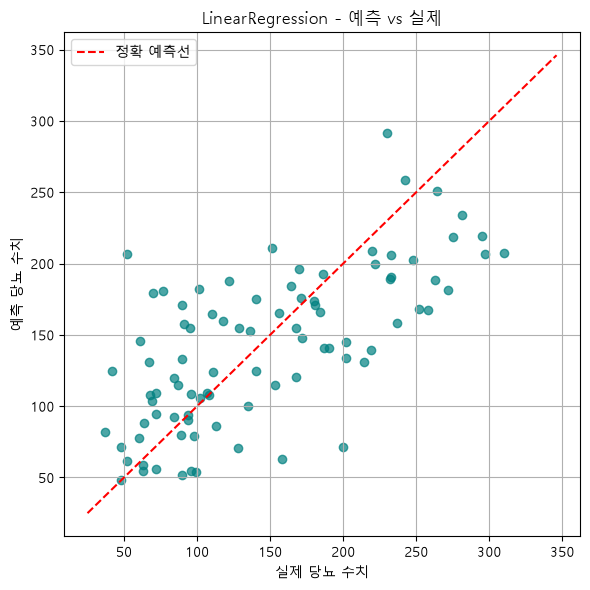

In [3]:


# 2. 데이터 로드
diabetes = load_diabetes()
X = diabetes.data                # 10개의 특성 (age, sex, bmi, bp, s1~s6)
y = diabetes.target              # 목표값: 당뇨병 진행도 (정수형 연속 값)

# 3. 학습/테스트 데이터 분리 (80:20 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. 선형 회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 5. 예측
y_pred = model.predict(X_test)

# 6. 평가 지표 출력
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("선형 회귀 - 당뇨병 예측")
print("MSE:", round(mse, 2))
print("R² Score:", round(r2, 3))

# 7. 회귀 계수 확인
coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': model.coef_
})
print("\n[회귀 계수]")
print(coef_df.sort_values(by="Coefficient", key=abs, ascending=False))

# 8. 예측 vs 실제 시각화
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='정확 예측선')
plt.xlabel("실제 당뇨 수치")
plt.ylabel("예측 당뇨 수치")
plt.title("LinearRegression - 예측 vs 실제")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


LinearRegression에서 튜닝 가능한 주요 파라미터

| 파라미터            | 설명                                                                   |
| --------------- | -------------------------------------------------------------------- |
| `fit_intercept` | 절편(Intercept)을 학습할 것인지 여부 (`True` 또는 `False`)                        |
| `normalize`     | 입력 특성을 정규화할지 여부 *(`normalize`는 deprecated → `StandardScaler` 사용 권장)* |
| `positive`      | 회귀 계수를 양수로만 제한할지 여부 (`False` 기본값)                                    |


In [4]:
# GridSearchCV로 하이퍼파라미터 튜닝 코드

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. 파이프라인 구성: 스케일링 + 선형 회귀
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# 2. 탐색할 파라미터 그리드 정의
param_grid = {
    'lr__fit_intercept': [True, False],
    'lr__positive': [False, True]
}

# 3. GridSearchCV 구성
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='r2',             # 또는 'neg_mean_squared_error'
    cv=5                      # 5-fold 교차 검증
)

# 4. 학습
grid.fit(X_train, y_train)

# 5. 최적 모델과 평가 출력
print("Best Params:", grid.best_params_)
print("Best R² Score (CV):", round(grid.best_score_, 3))

# 6. 테스트 데이터로 최종 성능 확인
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² Score:", r2_score(y_test, y_pred))


Best Params: {'lr__fit_intercept': True, 'lr__positive': False}
Best R² Score (CV): 0.449
Test MSE: 2900.193628493482
Test R² Score: 0.45260276297191937


## Lasso Regression


**Lasso 회귀 (L1 정규화)**는 가중치의 절댓값 합을 규제 항으로 추가하여 불필요한 특성의 계수를 0으로 만들어 자동 변수 선택 효과를 가집니다.

### 수식
$$
\text{Loss}_{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

- 변수 선택과 정규화 효과를 동시에 제공합니다.


Lasso 회귀 - R2: 0.4718547867276227
Lasso 회귀 - MSE: 2798.1934851697188


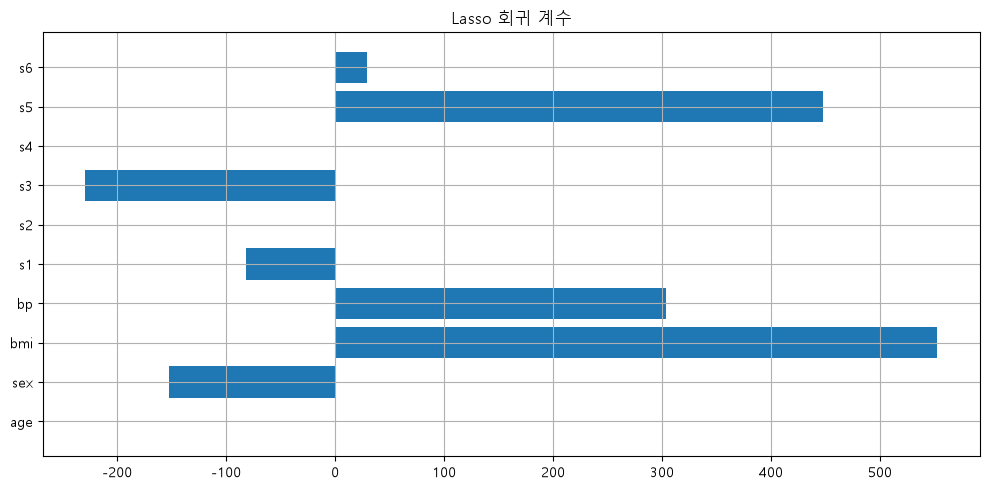

In [5]:

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("Lasso 회귀 - R2:", r2_score(y_test, y_pred_lasso))
print("Lasso 회귀 - MSE:", mean_squared_error(y_test, y_pred_lasso))

plt.figure(figsize=(10, 5))
plt.barh(diabetes.feature_names, lasso.coef_)
plt.title("Lasso 회귀 계수")
plt.grid(True)
plt.tight_layout()
plt.show()


최적 alpha: 1
최고 R² 점수 (CV 기준): 0.4541
테스트셋 R²: 0.4669
 테스트셋 MSE: 2824.57


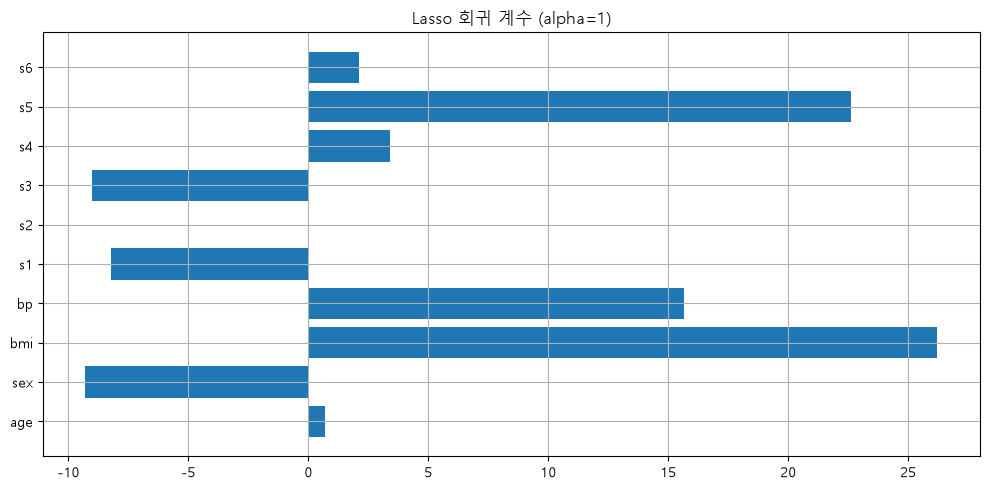

In [6]:
# Lasso 회귀 하이퍼파라미터 튜닝(alpha 최적화)
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. 파이프라인 구성: 스케일링 + Lasso 회귀
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

# 2. 하이퍼파라미터 탐색 범위
param_grid = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}

# 3. GridSearchCV 구성
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

# 4. 최적 하이퍼파라미터 및 성능 출력
print("최적 alpha:", grid.best_params_['lasso__alpha'])
print("최고 R² 점수 (CV 기준):", round(grid.best_score_, 4))

# 5. 테스트셋에서의 평가
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("테스트셋 R²:", round(r2_score(y_test, y_pred_best), 4))
print(" 테스트셋 MSE:", round(mean_squared_error(y_test, y_pred_best), 2))

# 6. 회귀 계수 시각화
best_lasso = best_model.named_steps['lasso']
plt.figure(figsize=(10, 5))
plt.barh(diabetes.feature_names, best_lasso.coef_)
plt.title(f"Lasso 회귀 계수 (alpha={grid.best_params_['lasso__alpha']})")
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
# sckit-learn의 모델들은 get_parms를 공통적으로 가지고 있다.
# 알고리즘이 사용할 수있는 하이퍼 파라미터를 알려준다.
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)
lasso.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': 10000,
 'positive': False,
 'precompute': False,
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'warm_start': False}

# Ridge Regression
- 릿지 회귀는 선형 회귀의 과적합 문제를 완화하기 위해 L2 정규화(패널티 항)를 추가한 모델이다.
- 회귀 계수의 크기를 줄이도록 제약을 걸어, 모델이 너무 복잡해지지 않도록 방지한다

$$
\text{Loss}_{\text{Ridge}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} w_j^2
$$

 
$$
\hat{y}_i = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_p x_p
$$

- α : 규제 강도 (정규화 파라미터), 클수록 모델이 단순해짐

$$
w_j: \quad \text{각 특성 } x_j \text{ 에 대한 회귀 계수}
$$





| 파라미터            | 설명                                              |
| --------------- | ----------------------------------------------- |
| `alpha`         | L2 패널티의 강도 (기본값: 1.0). 값이 클수록 계수가 작아짐 (과적합 방지)  |
| `fit_intercept` | 절편 포함 여부 (`True` 기본값)                           |
| `solver`        | 최적화 방식 (`auto`, `sparse_cg`, `saga` 등)          |
| `normalize`     | 특성 정규화 여부 (deprecated → `StandardScaler` 사용 권장) |


릿지 회귀 - 당뇨병 예측
MSE: 3077.42
R² Score: 0.419


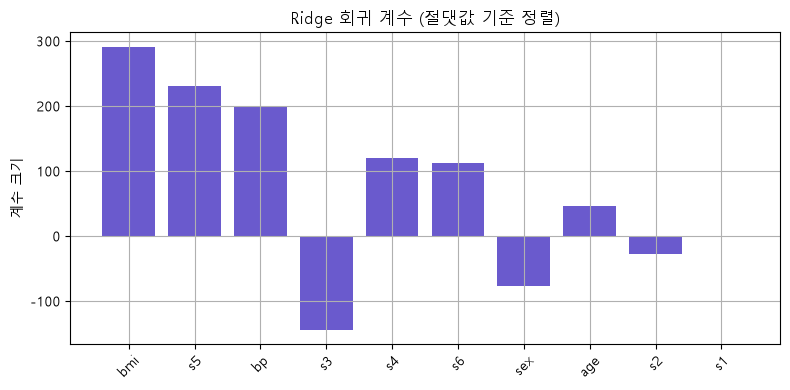

In [8]:

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 4. 릿지 회귀 모델 학습
ridge = Ridge(alpha=1.0)  # alpha가 클수록 규제가 강해짐
ridge.fit(X_train, y_train)

# 5. 예측 및 평가
y_pred = ridge.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("릿지 회귀 - 당뇨병 예측")
print("MSE:", round(mse, 2))
print("R² Score:", round(r2, 3))

# 6. 회귀 계수 시각화
coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': ridge.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color='slateblue')
plt.title("Ridge 회귀 계수 (절댓값 기준 정렬)")
plt.ylabel("계수 크기")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## ElasticNet Regression


**ElasticNet 회귀**는 L1과 L2 규제를 동시에 적용하는 회귀 알고리즘입니다.

### 수식
$$
\text{Loss} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha_1 \sum |w_j| + \alpha_2 \sum w_j^2
$$





ElasticNet 회귀 - R2: 0.09865421116113748
ElasticNet 회귀 - MSE: 4775.466767154695


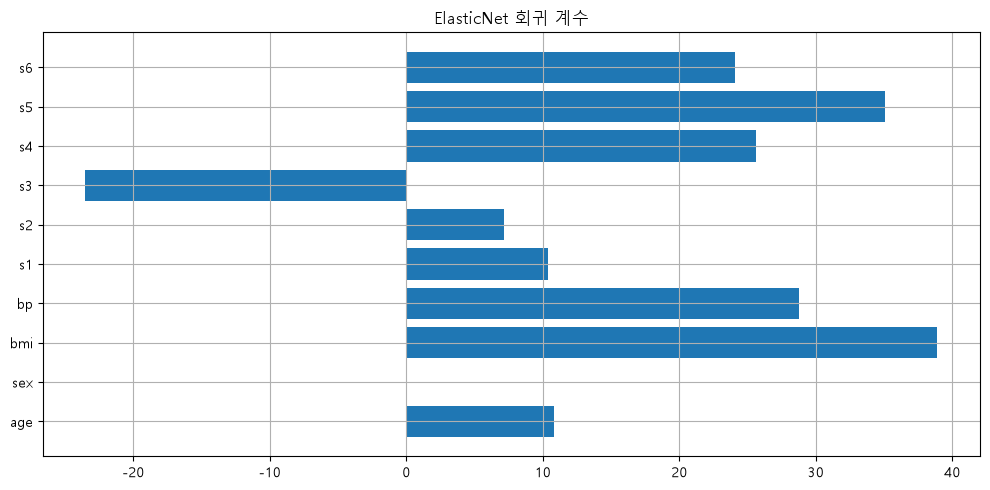

In [9]:

from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.1, l1_ratio=0.5)
enet.fit(X_train, y_train)
y_pred_enet = enet.predict(X_test)

print("ElasticNet 회귀 - R2:", r2_score(y_test, y_pred_enet))
print("ElasticNet 회귀 - MSE:", mean_squared_error(y_test, y_pred_enet))

plt.figure(figsize=(10, 5))
plt.barh(diabetes.feature_names, enet.coef_)
plt.title("ElasticNet 회귀 계수")
plt.grid(True)
plt.tight_layout()
plt.show()


ElasticNet 주요 하이퍼파라미터

| 하이퍼파라미터    | 설명                                          | 값의 범위                                | 영향 및 특징                                                                                                                   |
| ---------- | ------------------------------------------- | ------------------------------------ | ------------------------------------------------------------------------------------------------------------------------- |
| `alpha`    | 규제 강도 <br> 모델 복잡도를 조절하는 정규화 파라미터            | 실수, 일반적으로 0보다 큰 값 (예: `0.0001 ~ 10`) | - 값이 **클수록** 계수들이 더 0에 가까워짐 → **단순한 모델, 과적합 방지**<br>- 너무 크면 **과소적합** 가능                                                   |
| `l1_ratio` | L1과 L2 규제의 혼합 비율 <br> Lasso와 Ridge를 혼합하는 비율 | 0.0 \~ 1.0                           | - **1.0**: Lasso와 동일 (L1만 적용)<br>- **0.0**: Ridge와 동일 (L2만 적용)<br>- **0.5**: L1 50% + L2 50%<br>- **0.1\~0.9** 범위에서 조정 가능 |


최적 alpha: 0.1, 최적 l1_ratio: 0.1
최고 R² 점수 (CV 기준): 0.456
테스트셋 R²: 0.46
테스트셋 MSE: 2860.95


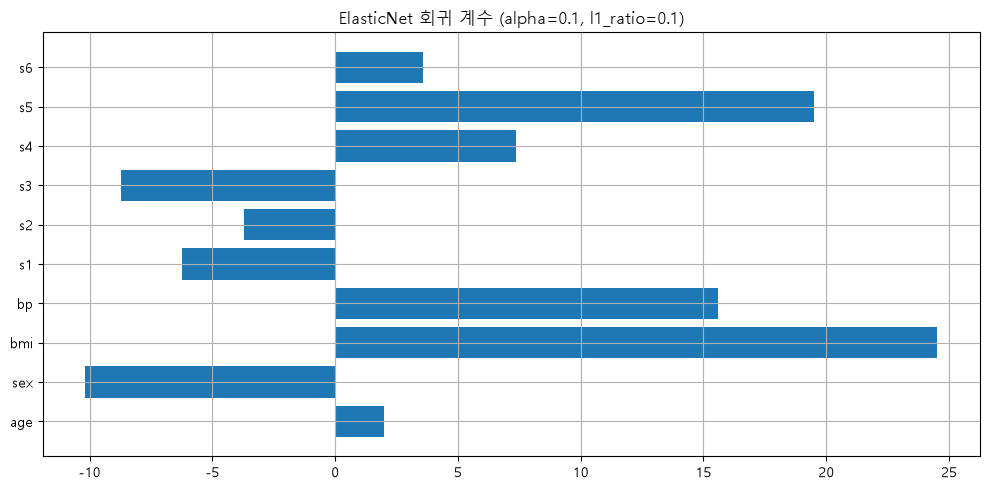

In [10]:
# ElasticNet 하이퍼파라미터 튜닝 (alpha, l1_ratio)
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. 파이프라인 구성 (스케일링 + ElasticNet)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('enet', ElasticNet(max_iter=10000))
])

# 2. 하이퍼파라미터 탐색 범위
param_grid = {
    'enet__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'enet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]  # 1.0은 Lasso, 0.0은 Ridge와 유사
}

# 3. 그리드 서치 (교차 검증 5폴드)
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

# 4. 최적 하이퍼파라미터 출력
best_alpha = grid.best_params_['enet__alpha']
best_l1_ratio = grid.best_params_['enet__l1_ratio']
print(f"최적 alpha: {best_alpha}, 최적 l1_ratio: {best_l1_ratio}")
print("최고 R² 점수 (CV 기준):", round(grid.best_score_, 4))

# 5. 테스트셋에서의 성능 확인
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("테스트셋 R²:", round(r2_score(y_test, y_pred_best), 4))
print("테스트셋 MSE:", round(mean_squared_error(y_test, y_pred_best), 2))

# 6. 회귀 계수 시각화
best_enet = best_model.named_steps['enet']
plt.figure(figsize=(10, 5))
plt.barh(diabetes.feature_names, best_enet.coef_)
plt.title(f"ElasticNet 회귀 계수 (alpha={best_alpha}, l1_ratio={best_l1_ratio})")
plt.grid(True)
plt.tight_layout()
plt.show()


## Polynomial Regression


**다항 회귀(Polynomial Regression)**는 선형 회귀로는 설명할 수 없는 비선형 관계를 모델링할 때 사용한다.

특성 x를 2차로 확장하면: \( y = w_0 + w_1 x + w_2 x^2 \)


| 조건                                   | 설명                                        |
| ------------------------------------ | ----------------------------------------- |
| 🔁 **입력 변수와 출력 변수 간의 관계가 곡선 형태인 경우** | 직선으로는 설명할 수 없는 관계일 때 (ex: 곡선, 포물선)        |
| 📈 **선형 회귀의 R² 성능이 낮은 경우**           | 잔차가 크게 남는다면 고차항을 추가해 개선 가능                |
| 🎯 **예측 정확도를 개선하고자 할 때**             | 단, 고차항이 많아질수록 과적합 위험 있음                   |
| 📊 **시각적으로 곡선 회귀선을 원할 때**            | 특히 feature가 1\~2차원일 때 효과적 시각화 가능          |
| 🧪 **특성의 상호작용(다항적 효과)을 반영하고 싶을 때**   | 예: $x_1^2$, $x_1 x_2$ 등을 통해 변수 간 곡선 관계 학습 |


<예시>  
- 의학 예시:
연령(age)과 질병 진행률 사이의 관계가 단순한 직선이 아닌 포물선 형태일 경우
→ 선형 회귀는 미스매칭 발생 → 다항 회귀 도입

- 경제학/물리학:
제품 가격이 너무 낮거나 너무 높을 때 수요가 감소 → 곡선 관계
→ 2차 혹은 3차 다항 회귀로 모델링


In [11]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train[:, [2]], y_train)  # BMI만 사용
y_pred_poly = poly_model.predict(X_test[:, [2]])

print("Polynomial 회귀 (BMI) - R2:", r2_score(y_test, y_pred_poly))
print("Polynomial 회귀 (BMI) - MSE:", mean_squared_error(y_test, y_pred_poly))


Polynomial 회귀 (BMI) - R2: 0.2289715971205667
Polynomial 회귀 (BMI) - MSE: 4085.025480871632


Polynomial Regression 하이퍼파라미터

| 파라미터 이름               | 설명                                                         | 추천값/예시            |
| --------------------- | ---------------------------------------------------------- | ----------------- |
| `poly__degree`        | 다항식 차수<br>모델이 학습할 수 있는 곡선의 복잡도                             | 1~~5 (보통 2~~3 적절) |
| `poly__include_bias`  | 절편 $x^0$ 항 포함 여부<br>LinearRegression 자체 절편 있음 → 보통 `False` | `False`           |
| `lr__fit_intercept`   | 선형 회귀에서 절편 포함 여부                                           | `True`            |
| `lr__normalize` (구버전) | 특성 정규화 여부 (scikit-learn 1.0 미만에서 사용)                       | 사용 안함             |


In [12]:
# 하이퍼파라미터 튜닝 (GridSearchCV 적용)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

# 1. 파이프라인 구성: PolynomialFeatures + LinearRegression
pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('lr', LinearRegression())
])

# 2. 하이퍼파라미터 후보
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5]  # 1~5차까지 실험
}

# 3. GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2')
grid.fit(X_train[:, [2]], y_train)  # BMI만 사용

# 4. 최적 파라미터 및 테스트셋 성능 출력
best_degree = grid.best_params_['poly__degree']
print("최적 다항 차수 (degree):", best_degree)
print("최고 R² (교차 검증):", round(grid.best_score_, 4))

# 테스트셋 평가
y_pred_best = grid.best_estimator_.predict(X_test[:, [2]])
print("테스트셋 R²:", round(r2_score(y_test, y_pred_best), 4))
print("테스트셋 MSE:", round(mean_squared_error(y_test, y_pred_best), 2))


최적 다항 차수 (degree): 1
최고 R² (교차 검증): 0.322
테스트셋 R²: 0.2334
테스트셋 MSE: 4061.83


## Decision Tree Regression


**의사결정트리 회귀 (Decision Tree Regression)**은 데이터를 조건에 따라 분할하여 트리 형태로 예측하는 회귀 모델입니다.

- 비선형 관계도 잘 모델링 가능
- 과적합 방지를 위해 `max_depth`, `min_samples_leaf` 설정 필요

※  주요 하이퍼파라미터 설명

- `max_depth`: 트리의 최대 깊이. 과적합 방지를 위해 적절한 깊이 제한이 필요합니다.
- `min_samples_split`: 내부 노드를 분할하기 위한 최소 샘플 수.
- `min_samples_leaf`: 리프 노드가 되기 위한 최소 샘플 수.
- `max_features`: 각 분할에 사용할 최대 특성 수.
- `random_state`: 결과 재현성을 위한 난수 시드.


Decision Tree 회귀 - R2: 0.3263754171777956
Decision Tree 회귀 - MSE: 3568.9652613232283


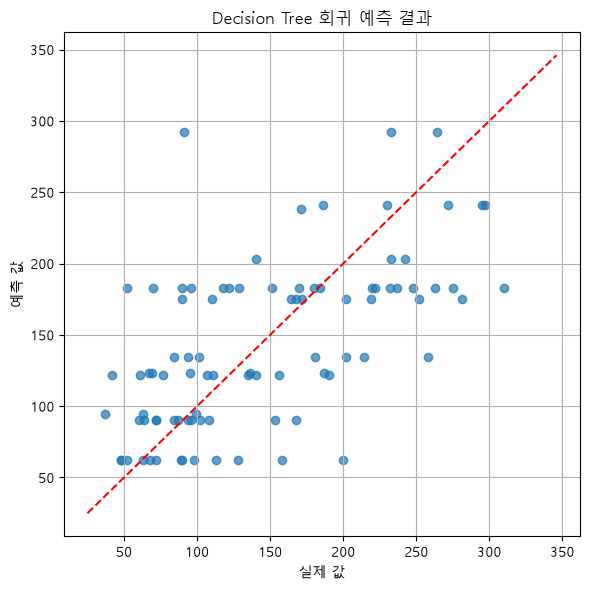

In [13]:

from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree 회귀 - R2:", r2_score(y_test, y_pred_tree))
print("Decision Tree 회귀 - MSE:", mean_squared_error(y_test, y_pred_tree))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_tree, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Decision Tree 회귀 예측 결과")
plt.xlabel("실제 값")
plt.ylabel("예측 값")
plt.grid(True)
plt.tight_layout()
plt.show()


## 부록. DT 그림 표시
- uv add pydotplus  로 먼저 설치해야 함
- graphviz-2.38.msi 다운받은 후에 설치
https://graphviz.gitlab.io/_pages/Download/Download_windows.html

In [14]:
#!uv add pydotplus

In [5]:
from pydotplus import graph_from_dot_data
from sklearn.tree import export_graphviz
from IPython.display import Image #CART Tree 그림
import pydotplus
import os

In [6]:
feature_names = diabetes.feature_names
target_name = np.array(['No', 'Yes'])

In [7]:
feature_names = diabetes.feature_names  # 또는 직접 리스트로 지정 가능

# export_graphviz를 이용해 dot 형식으로 트리 저장
dot_data = export_graphviz(tree_model,
                           out_file=None,
                           filled=True,
                           rounded=True,
                           special_characters=True,
                           feature_names=feature_names)

# dot 데이터를 기반으로 graphviz 객체 생성 및 이미지 저장
graph = graph_from_dot_data(dot_data)
graph.write_png("tree.png")  # PNG 파일로 저장


True

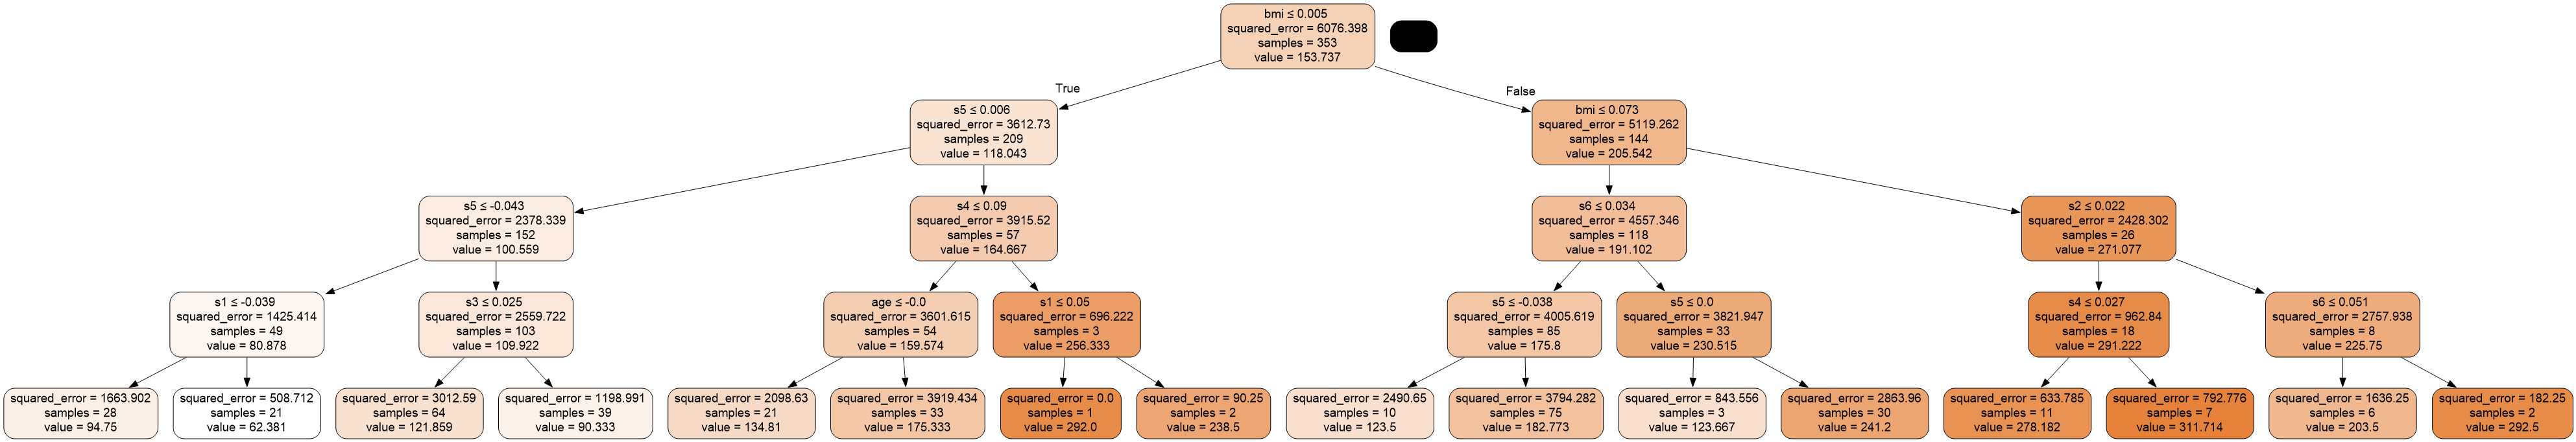

In [8]:
dt_graph = pydotplus.graph_from_dot_data(dot_data)
Image(dt_graph.create_png())

DecisionTreeRegressor 하이퍼파라미터


| 파라미터 이름             | 설명                                          |
| ------------------- | ------------------------------------------- |
| `max_depth`         | 트리의 최대 깊이. 깊을수록 복잡한 모델. 과적합 방지에 사용          |
| `min_samples_split` | 내부 노드를 분할하기 위한 최소 샘플 수. 클수록 분할 억제됨 (과적합 감소) |
| `min_samples_leaf`  | 리프 노드가 가져야 하는 최소 샘플 수. 클수록 일반화에 도움          |
| `max_leaf_nodes`    | 생성할 수 있는 최대 리프 노드 수 제한                      |
| `max_features`      | 분할 시 고려할 최대 특성 수 (랜덤성 유도 가능)                |
| `random_state`      | 결과 재현을 위한 난수 시드 값                           |


In [10]:
# DecisionTreeRegressor 하이퍼파라미터 튜닝 코드 (GridSearchCV)

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# 1. 튜닝할 파라미터 그리드 정의
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 4, 6, 10],
    'min_samples_leaf': [1, 2, 4, 6]
}

# 2. GridSearchCV로 탐색
grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 3. 학습
grid.fit(X_train, y_train)

# 4. 최적 모델 및 성능 출력
print("최적 하이퍼파라미터:", grid.best_params_)
print("최고 R² (교차검증):", round(grid.best_score_, 4))

# 5. 테스트셋 성능 확인
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("테스트셋 R²:", round(r2_score(y_test, y_pred_best), 4))
print("테스트셋 MSE:", round(mean_squared_error(y_test, y_pred_best), 2))


최적 하이퍼파라미터: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
최고 R² (교차검증): 0.3516
테스트셋 R²: 0.2949
테스트셋 MSE: 3735.5


## Support Vector Regression (SVR)


**서포트 벡터 회귀 (SVR)**는 예측 마진 내 오류는 무시하고 중요한 경계 데이터에만 집중하여 학습한다.

- 이상치에 강건
- `kernel`, `C`, `epsilon` 파라미터로 조절 가능

※  주요 하이퍼파라미터 설명

- `C`: 마진 위반에 대한 벌점. 클수록 과적합 가능성 있음.
- `epsilon`: 마진 허용 범위. 이 범위 내의 오차는 무시됨.
- `kernel`: 커널 종류 (`linear`, `rbf`, `poly`, `sigmoid`).
- `gamma`: RBF, poly 커널에서의 감쇠 계수.


In [9]:

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.2)
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)

print("SVR 회귀 - R2:", r2_score(y_test, y_pred_svr))
print("SVR 회귀 - MSE:", mean_squared_error(y_test, y_pred_svr))


SVR 회귀 - R2: 0.49385496327697154
SVR 회귀 - MSE: 2681.6332113171125


SVR 주요 하이퍼파라미터

| 하이퍼파라미터   | 설명                            | 주요 역할 및 효과                                      | 예시값                     |
| --------- | ----------------------------- | ----------------------------------------------- | ----------------------- |
| `kernel`  | 커널 함수 선택 (비선형 가능)             | `'linear'`, `'poly'`, `'rbf'`, `'sigmoid'` 중 선택 | `'rbf'` (기본)            |
| `C`       | 오류 허용도 제어 (규제 강도)             | 클수록 훈련 데이터에 더 민감 → 과적합 가능성 ↑                    | 0.1 \~ 100              |
| `epsilon` | 오차 허용 마진 (ε-insensitive zone) | 예측이 이 범위 안에 있으면 패널티 부과 안함                       | 0.01 \~ 1.0             |
| `gamma`   | RBF, poly, sigmoid 커널에서 영향 범위 | 작을수록 부드러운 결정 경계, 클수록 복잡                         | `'scale'`, `'auto'`, 실수 |

***표준화 (StandardScaler)는 필수입니다. SVR은 거리 기반 커널을 사용하기 때문에 모든 특성이 같은 스케일이어야 한다.***

In [21]:
# SVR 하이퍼파라미터 튜닝 코드 (GridSearchCV)

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. 파이프라인 구성
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# 2. 파라미터 후보 정의
param_grid = {
    'svr__kernel': ['rbf'],
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.2, 0.5],
    'svr__gamma': ['scale', 'auto']
}

# 3. GridSearchCV
grid = GridSearchCV(
    svr_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 4. 학습
grid.fit(X_train, y_train)

# 5. 결과 출력
print("최적 하이퍼파라미터:", grid.best_params_)
print("최고 R² (교차검증):", round(grid.best_score_, 4))

# 6. 테스트셋 성능 평가
y_pred_best = grid.best_estimator_.predict(X_test)
print("테스트셋 R²:", round(r2_score(y_test, y_pred_best), 4))
print("테스트셋 MSE:", round(mean_squared_error(y_test, y_pred_best), 2))


최적 하이퍼파라미터: {'svr__C': 10, 'svr__epsilon': 0.5, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
최고 R² (교차검증): 0.4135
테스트셋 R²: 0.4942
테스트셋 MSE: 2679.95


## MLP Regression

**신경망 회귀 (MLP Regressor)**는 입력 → 은닉층 → 출력층으로 구성된 딥러닝 기반 회귀 모델입니다.

- 복잡한 비선형 관계도 학습 가능
- 뉴런 수, 층 수, 활성화 함수 조정 가능

### 수식
\[
y = f(Wx + b)
\]
(여기서 \( f \)는 활성화 함수, 예: ReLU, tanh)


![MLP Regression](https://upload.wikimedia.org/wikipedia/commons/4/46/Colored_neural_network.svg)

※  주요 하이퍼파라미터 설명

- `hidden_layer_sizes`: 은닉층의 구조 (예: (100,), (50, 30)).
- `activation`: 활성화 함수 (`relu`, `tanh`, `logistic`).
- `solver`: 최적화 알고리즘 (`adam`, `lbfgs`, `sgd`).
- `alpha`: L2 규제 항.
- `learning_rate_init`: 초기 학습률.
- `max_iter`: 최대 반복 수.


In [ ]:

from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)

print("MLP 회귀 - R2:", r2_score(y_test, y_pred_mlp))
print("MLP 회귀 - MSE:", mean_squared_error(y_test, y_pred_mlp))


MLPRegressor 주요 하이퍼파라미터

| 파라미터 이름              | 설명                 | 예시 / 기본값                             |
| -------------------- | ------------------ | ------------------------------------ |
| `hidden_layer_sizes` | 은닉층 크기와 개수 (튜플 형태) | `(100,)`, `(100, 50)`                |
| `activation`         | 활성화 함수             | `'relu'`(기본), `'tanh'`, `'logistic'` |
| `solver`             | 가중치 최적화 방법         | `'adam'`(기본), `'sgd'`, `'lbfgs'`     |
| `alpha`              | L2 규제 계수 (과적합 방지)  | `0.0001`                             |
| `learning_rate`      | 학습률 스케줄링 방식        | `'constant'`, `'adaptive'`           |
| `learning_rate_init` | 초기 학습률             | `0.001`, `0.01`                      |
| `max_iter`           | 최대 반복 수 (epoch 수)  | 기본 200                               |
| `early_stopping`     | 조기 종료 여부 (과적합 방지)  | `True / False`                       |
| `random_state`       | 랜덤 시드 (결과 재현용)     | 정수                                   |


In [ ]:
# MLP 하이퍼파라미터 튜닝

from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# 1. 파이프라인 구성
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=1000, random_state=42))
])

# 2. 파라미터 후보 설정
param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate_init': [0.001, 0.01],
}

# 3. GridSearchCV
grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

# 4. 학습
grid.fit(X_train, y_train)

# 5. 결과 출력
print("최적 하이퍼파라미터:", grid.best_params_)
print("최고 R² (CV):", round(grid.best_score_, 4))

# 6. 테스트셋 성능 확인
y_pred_best = grid.best_estimator_.predict(X_test)
print("테스트셋 R²:", round(r2_score(y_test, y_pred_best), 4))
print("테스트셋 MSE:", round(mean_squared_error(y_test, y_pred_best), 2))


최적 하이퍼파라미터: {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (100,), 'mlp__learning_rate_init': 0.001}
최고 R² (CV): 0.4057
테스트셋 R²: 0.4266
테스트셋 MSE: 3038.01


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
